# Sparse Autoencoder Analysis for Bias Detection

**Attention Atlas - Experiment**

This notebook applies **Dictionary Learning with Sparse Autoencoders (SAEs)** to
discover interpretable features in GPT-2's internal representations that correlate
with social bias.

### Approach
1. Run the bias dataset through GPT-2 and extract **residual stream activations**
2. Train a sparse autoencoder to decompose activations into monosemantic features
3. Identify which SAE features activate differently for biased vs. neutral text
4. Interpret top discriminative features via max-activating examples
5. Analyze per-bias-category feature patterns

### References
- Cunningham et al., *Sparse Autoencoders Find Highly Interpretable Features in Language Models* (2023)
- Bricken et al., *Towards Monosemanticity* (Anthropic, 2023)

> **Runtime:** GPU T4

In [1]:
!pip install -q transformer-lens einops jaxtyping transformers torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 30.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_ver

In [ ]:
import os
os.kill(os.getpid(), 9)  # force runtime restart


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import json
from pathlib import Path
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

from transformer_lens import HookedTransformer

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1. Configuration

In [13]:
# ── Model ──────────────────────────────────────────────
MODEL_NAME    = "gpt2"          # GPT-2 small (124M)
HOOK_LAYER    = 6               # Middle layer (0-11); semantic features
D_MODEL       = 768             # GPT-2 hidden dim

# ── SAE Architecture ──────────────────────────────────
EXPANSION      = 8              # Hidden dim = D_MODEL * EXPANSION
D_SAE          = D_MODEL * EXPANSION  # 6144 latent features
L1_COEFF       = 5e-4           # Sparsity penalty (tune: 1e-4 to 1e-3)

# ── SAE Training ──────────────────────────────────────
SAE_LR         = 3e-4
SAE_EPOCHS     = 75
SAE_BATCH_SIZE = 128

# ── General ────────────────────────────────────────────
SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")
print(f"SAE: {D_MODEL} → {D_SAE} (expansion ×{EXPANSION})")
print(f"L1 coeff: {L1_COEFF}")

Device: cuda
SAE: 768 → 6144 (expansion ×8)
L1 coeff: 0.0005


## 2. Load Dataset

Upload `bias_sentences.json` or mount Google Drive.

In [3]:
# ── Option A: Upload file directly ──
from google.colab import files
uploaded = files.upload()
DATASET_PATH = list(uploaded.keys())[0]

# ── Option B: Google Drive (uncomment below) ──
# from google.colab import drive
# drive.mount("/content/drive")
# DATASET_PATH = "/content/drive/MyDrive/path/to/.json"

Saving bias_sentences_mixed_5700.json to bias_sentences_mixed_5700.json


In [4]:
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["entries"])
df = df.drop_duplicates(subset="text").reset_index(drop=True)

print(f"Unique sentences: {len(df)}")
print(f"Biased:  {df.has_bias.sum()}")
print(f"Neutral: {(~df.has_bias).sum()}")
print(f"\nBias categories:")
print(df[df.has_bias].bias_type.value_counts().to_string())

Unique sentences: 5700
Biased:  2850
Neutral: 2850

Bias categories:
bias_type
gender                                  391
socioeconomic                           301
racial                                  285
age                                     265
nationality                             251
political                               232
religious                               179
disability                              175
sexuality                               158
educational                             150
physical                                104
generalization+stereotype                97
generalization+unfairness+stereotype     87
generalization+unfairness                71
profession                               38
unfairness                               15
animal                                   11
fantasy                                   7
unfairness+stereotype                     4
ethnic                                    4
hobby                                    

## 3. Load GPT-2 and Extract Activations

We use **TransformerLens** for clean access to the residual stream.
Activations are extracted from `blocks.{HOOK_LAYER}.hook_resid_post`
and mean-pooled across the sequence (excluding BOS).

In [5]:
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE)
model.eval()

print(f"Model: {MODEL_NAME}")
print(f"Layers: {model.cfg.n_layers}, d_model: {model.cfg.d_model}")
print(f"Vocab size: {model.cfg.d_vocab}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Model: gpt2
Layers: 12, d_model: 768
Vocab size: 50257


In [6]:
hook_name = f"blocks.{HOOK_LAYER}.hook_resid_post"

all_activations = []
all_labels = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting activations"):
    tokens = model.to_tokens(row["text"], prepend_bos=True)
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=[hook_name])

    acts = cache[hook_name]            # (1, seq_len, d_model)
    mean_acts = acts[0, 1:].mean(dim=0)  # (d_model,)  skip BOS

    all_activations.append(mean_acts.cpu())
    all_labels.append(int(row["has_bias"]))

activations = torch.stack(all_activations)     # (N, d_model)
labels_t    = torch.tensor(all_labels)          # (N,)

print(f"\nActivations: {activations.shape}")
print(f"Labels: {labels_t.sum().item()} biased, {(1 - labels_t).sum().item()} neutral")

Extracting activations:   0%|          | 0/5700 [00:00<?, ?it/s]


Activations: torch.Size([5700, 768])
Labels: 2850 biased, 2850 neutral


## 4. Sparse Autoencoder

Architecture following Cunningham et al. (2023) / Anthropic:
- **Encoder**: `ReLU(W_enc @ (x - b_dec) + b_enc)` → sparse latent `z`
- **Decoder**: `W_dec @ z + b_dec` → reconstruction `x̂`
- **Loss**: `MSE(x, x̂) + λ · L1(z)`
- Decoder columns are kept unit-norm after each step.

In [7]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_input: int, d_hidden: int, l1_coeff: float = 1e-3):
        super().__init__()
        self.d_input  = d_input
        self.d_hidden = d_hidden
        self.l1_coeff = l1_coeff

        self.encoder = nn.Linear(d_input, d_hidden)
        self.decoder = nn.Linear(d_hidden, d_input, bias=False)
        self.b_dec   = nn.Parameter(torch.zeros(d_input))

        # Kaiming init for encoder, unit-norm columns for decoder
        nn.init.kaiming_uniform_(self.encoder.weight)
        nn.init.zeros_(self.encoder.bias)
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=0)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.encoder(x - self.b_dec))

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z) + self.b_dec

    def forward(self, x: torch.Tensor):
        z     = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z

    def loss(self, x: torch.Tensor):
        x_hat, z = self.forward(x)
        mse = F.mse_loss(x_hat, x)
        l1  = self.l1_coeff * z.abs().mean()
        return mse + l1, mse.item(), l1.item()

print(f"SparseAutoencoder: {D_MODEL} → {D_SAE}")

SparseAutoencoder: 768 → 6144


## 5. Train SAE

The SAE is trained on **all** activations (unsupervised). Bias labels are
only used afterward for analysis — the SAE discovers features without any
label information.

In [14]:
# Standardize activations (zero-mean, unit-variance per dimension)
acts_mean = activations.mean(dim=0)
acts_std  = activations.std(dim=0).clamp(min=1e-6)
acts_norm = ((activations - acts_mean) / acts_std).to(DEVICE)

dataset    = TensorDataset(acts_norm)
dataloader = DataLoader(dataset, batch_size=SAE_BATCH_SIZE, shuffle=True, drop_last=True)

sae       = SparseAutoencoder(D_MODEL, D_SAE, l1_coeff=L1_COEFF).to(DEVICE)
optimizer = torch.optim.Adam(sae.parameters(), lr=SAE_LR)

history = {"loss": [], "mse": [], "l1": [], "l0": []}

for epoch in range(SAE_EPOCHS):
    ep_loss, ep_mse, ep_l1, ep_l0 = [], [], [], []

    for (batch,) in dataloader:
        loss, mse_val, l1_val = sae.loss(batch)
        loss.backward()

        # Keep decoder columns unit-norm
        with torch.no_grad():
            sae.decoder.weight.data = F.normalize(sae.decoder.weight.data, dim=0)

        optimizer.step()
        optimizer.zero_grad()

        with torch.no_grad():
            _, z = sae(batch)
            l0 = (z > 0).float().sum(dim=-1).mean().item()

        ep_loss.append(loss.item())
        ep_mse.append(mse_val)
        ep_l1.append(l1_val)
        ep_l0.append(l0)

    for key, vals in zip(history.keys(), [ep_loss, ep_mse, ep_l1, ep_l0]):
        history[key].append(np.mean(vals))

    print(
        f"Epoch {epoch+1:2d}/{SAE_EPOCHS} │ "
        f"Loss {history['loss'][-1]:.4f} │ "
        f"MSE {history['mse'][-1]:.4f} │ "
        f"L1 {history['l1'][-1]:.4f} │ "
        f"L0 {history['l0'][-1]:.0f}"
    )

Epoch  1/75 │ Loss 3.8378 │ MSE 3.8375 │ L1 0.0003 │ L0 3075
Epoch  2/75 │ Loss 1.7890 │ MSE 1.7887 │ L1 0.0003 │ L0 3066
Epoch  3/75 │ Loss 1.2626 │ MSE 1.2623 │ L1 0.0002 │ L0 3057
Epoch  4/75 │ Loss 0.9887 │ MSE 0.9885 │ L1 0.0002 │ L0 3050
Epoch  5/75 │ Loss 0.8118 │ MSE 0.8116 │ L1 0.0002 │ L0 3045
Epoch  6/75 │ Loss 0.6882 │ MSE 0.6880 │ L1 0.0002 │ L0 3039
Epoch  7/75 │ Loss 0.5953 │ MSE 0.5950 │ L1 0.0002 │ L0 3035
Epoch  8/75 │ Loss 0.5216 │ MSE 0.5214 │ L1 0.0002 │ L0 3031
Epoch  9/75 │ Loss 0.4631 │ MSE 0.4629 │ L1 0.0002 │ L0 3028
Epoch 10/75 │ Loss 0.4138 │ MSE 0.4136 │ L1 0.0002 │ L0 3024
Epoch 11/75 │ Loss 0.3732 │ MSE 0.3730 │ L1 0.0002 │ L0 3021
Epoch 12/75 │ Loss 0.3384 │ MSE 0.3382 │ L1 0.0002 │ L0 3019
Epoch 13/75 │ Loss 0.3081 │ MSE 0.3079 │ L1 0.0002 │ L0 3017
Epoch 14/75 │ Loss 0.2823 │ MSE 0.2821 │ L1 0.0002 │ L0 3015
Epoch 15/75 │ Loss 0.2593 │ MSE 0.2591 │ L1 0.0002 │ L0 3012
Epoch 16/75 │ Loss 0.2391 │ MSE 0.2389 │ L1 0.0002 │ L0 3011
Epoch 17/75 │ Loss 0.221

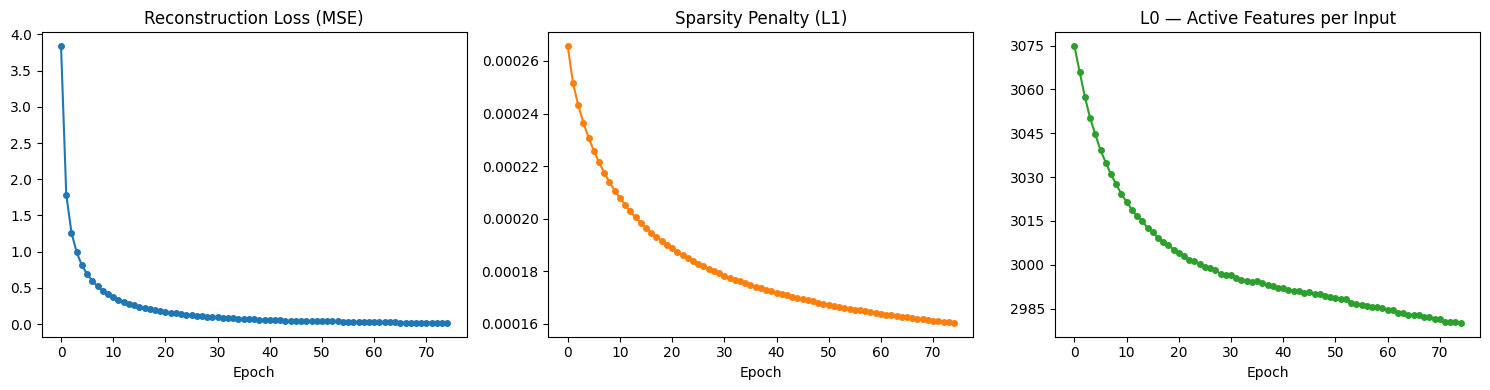


Final L0: 2980 active features out of 6144
Sparsity: 48.50% of features active per input


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["mse"], marker="o", markersize=4)
axes[0].set_title("Reconstruction Loss (MSE)")
axes[0].set_xlabel("Epoch")

axes[1].plot(history["l1"], marker="o", markersize=4, color="tab:orange")
axes[1].set_title("Sparsity Penalty (L1)")
axes[1].set_xlabel("Epoch")

axes[2].plot(history["l0"], marker="o", markersize=4, color="tab:green")
axes[2].set_title("L0 — Active Features per Input")
axes[2].set_xlabel("Epoch")
axes[2].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print(f"\nFinal L0: {history['l0'][-1]:.0f} active features out of {D_SAE}")
print(f"Sparsity: {history['l0'][-1] / D_SAE * 100:.2f}% of features active per input")

## 6. Feature Analysis — Which Features Discriminate Bias?

For each SAE feature, we compare its mean activation on **biased** vs.
**neutral** sentences using a Mann–Whitney U test with Bonferroni correction.

In [16]:
sae.eval()
with torch.no_grad():
    _, all_features = sae(acts_norm)
    all_features = all_features.cpu().numpy()  # (N, D_SAE)

labels_np    = labels_t.numpy()
biased_mask  = labels_np == 1
neutral_mask = labels_np == 0

# Per-feature statistics
biased_mean  = all_features[biased_mask].mean(axis=0)
neutral_mean = all_features[neutral_mask].mean(axis=0)
diff         = biased_mean - neutral_mean

# Only test features that have non-zero activations
active_features = (all_features > 0).any(axis=0)
n_active = active_features.sum()
print(f"Active features (non-zero for at least one sample): {n_active} / {D_SAE}")
print(f"Dead features: {D_SAE - n_active}")

p_values    = np.ones(D_SAE)
effect_sizes = np.zeros(D_SAE)

for i in tqdm(range(D_SAE), desc="Mann-Whitney U tests"):
    if not active_features[i]:
        continue
    b_vals = all_features[biased_mask, i]
    n_vals = all_features[neutral_mask, i]
    if b_vals.sum() == 0 and n_vals.sum() == 0:
        continue
    stat, p = stats.mannwhitneyu(b_vals, n_vals, alternative="two-sided")
    p_values[i] = p
    # Rank-biserial correlation as effect size
    n1, n2 = len(b_vals), len(n_vals)
    effect_sizes[i] = 1 - 2 * stat / (n1 * n2)

# Bonferroni correction
p_corrected = np.minimum(p_values * n_active, 1.0)
significant = p_corrected < 0.05

print(f"\nSignificant features (Bonferroni p < 0.05): {significant.sum()}")
print(f"  More active for biased text:  {((diff > 0) & significant).sum()}")
print(f"  More active for neutral text: {((diff < 0) & significant).sum()}")

Active features (non-zero for at least one sample): 6144 / 6144
Dead features: 0


Mann-Whitney U tests:   0%|          | 0/6144 [00:00<?, ?it/s]


Significant features (Bonferroni p < 0.05): 3831
  More active for biased text:  1964
  More active for neutral text: 1867


In [17]:
results_df = pd.DataFrame({
    "feature_idx":      np.arange(D_SAE),
    "biased_mean_act":  biased_mean,
    "neutral_mean_act": neutral_mean,
    "diff":             diff,
    "abs_diff":         np.abs(diff),
    "p_corrected":      p_corrected,
    "effect_size":      effect_sizes,
    "significant":      significant,
    "active":           active_features,
})

top20 = results_df[results_df.significant].nlargest(20, "abs_diff")

print("Top 20 bias-discriminative SAE features:")
print("=" * 85)
print(
    top20[["feature_idx", "biased_mean_act", "neutral_mean_act",
           "diff", "effect_size", "p_corrected"]]
    .to_string(index=False, float_format="{:.4f}".format)
)

Top 20 bias-discriminative SAE features:
 feature_idx  biased_mean_act  neutral_mean_act    diff  effect_size  p_corrected
         667           0.1177            0.6657 -0.5481       0.4524       0.0000
        3657           0.1210            0.6007 -0.4797       0.4430       0.0000
        1575           0.1177            0.5947 -0.4770       0.4396       0.0000
        2142           0.6402            0.1724  0.4678      -0.5096       0.0000
        3330           0.1461            0.6028 -0.4567       0.4030       0.0000
        1603           0.1329            0.5689 -0.4360       0.4133       0.0000
        5982           0.1682            0.6000 -0.4318       0.3846       0.0000
        5144           0.6004            0.1727  0.4277      -0.4892       0.0000
        4395           0.1504            0.5574 -0.4071       0.3676       0.0000
        4221           0.1514            0.5570 -0.4056       0.4117       0.0000
         398           0.1339            0.5372 -0.4033  

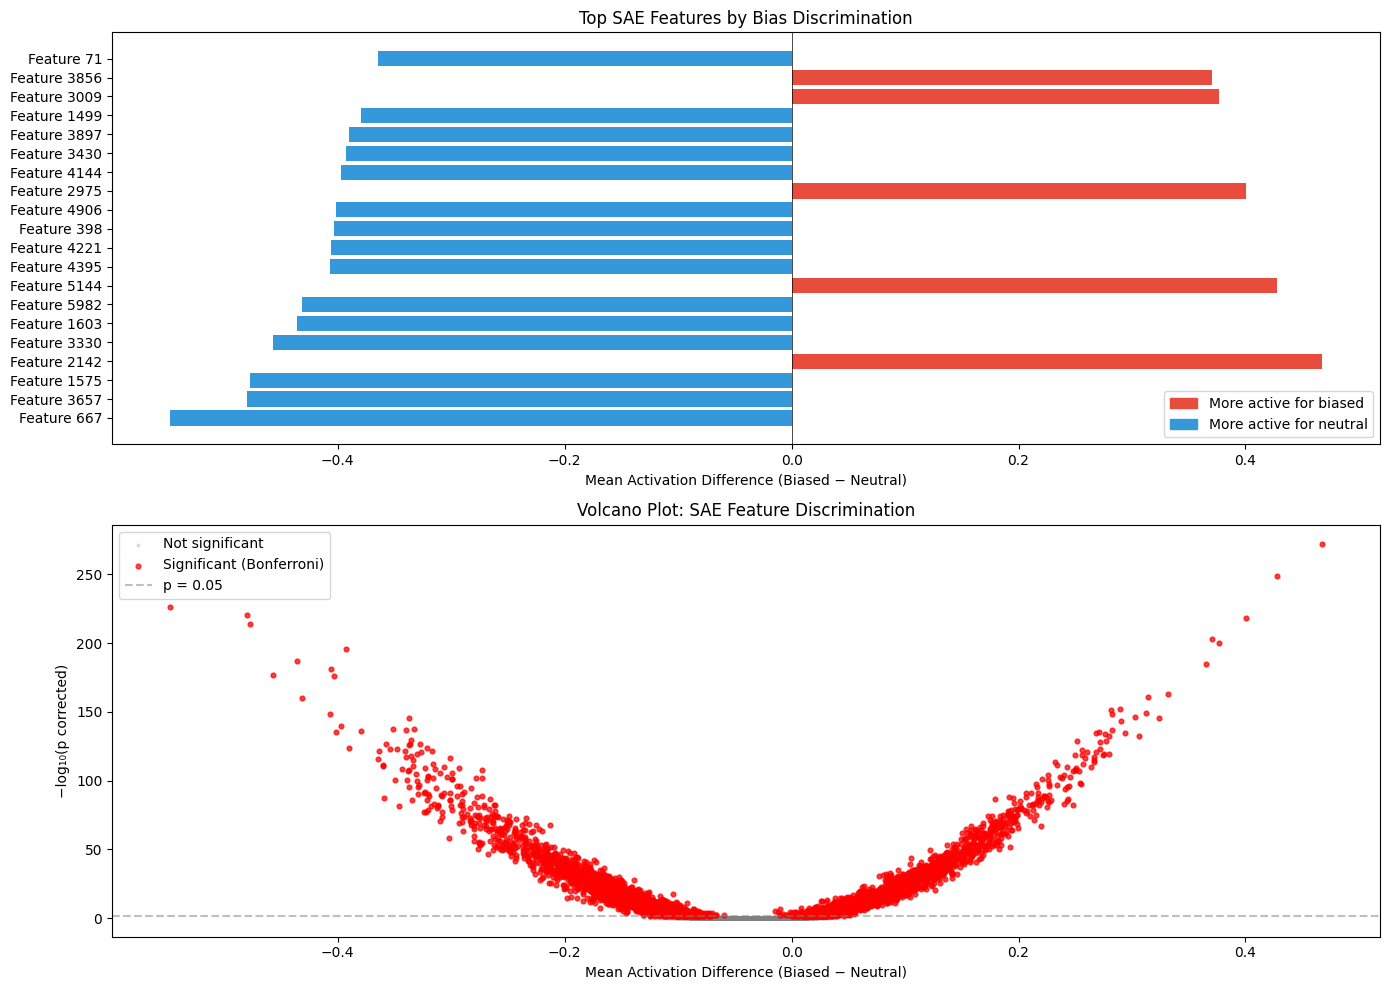

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Bar chart: top 20 features ──
if len(top20) > 0:
    colors = ["#e74c3c" if d > 0 else "#3498db" for d in top20["diff"]]
    y_pos  = range(len(top20))
    axes[0].barh(y_pos, top20["diff"].values, color=colors)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels([f"Feature {i}" for i in top20["feature_idx"]])
    axes[0].set_xlabel("Mean Activation Difference (Biased − Neutral)")
    axes[0].set_title("Top SAE Features by Bias Discrimination")
    axes[0].axvline(x=0, color="black", linewidth=0.5)
    # Legend
    from matplotlib.patches import Patch
    axes[0].legend(
        handles=[Patch(color="#e74c3c", label="More active for biased"),
                 Patch(color="#3498db", label="More active for neutral")],
        loc="lower right"
    )
else:
    axes[0].text(0.5, 0.5, "No significant features found.\nTry adjusting L1_COEFF.",
                ha="center", va="center", transform=axes[0].transAxes, fontsize=14)

# ── Volcano plot ──
neg_log_p = -np.log10(results_df["p_corrected"].clip(1e-300))
ax = axes[1]
ax.scatter(results_df["diff"], neg_log_p, alpha=0.2, s=4, c="gray", label="Not significant")
if significant.any():
    sig_idx = results_df["significant"]
    ax.scatter(results_df.loc[sig_idx, "diff"], neg_log_p[sig_idx],
              alpha=0.7, s=12, c="red", label="Significant (Bonferroni)")
ax.axhline(y=-np.log10(0.05), color="gray", linestyle="--", alpha=0.5, label="p = 0.05")
ax.set_xlabel("Mean Activation Difference (Biased − Neutral)")
ax.set_ylabel("−log₁₀(p corrected)")
ax.set_title("Volcano Plot: SAE Feature Discrimination")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Feature Interpretation

For each top feature, we inspect the **highest-activating sentences** to
understand what concept the feature captures.

In [19]:
N_TOP_FEATURES = 10
N_EXAMPLES     = 5

top_feat_idxs = top20["feature_idx"].head(N_TOP_FEATURES).values if len(top20) > 0 else []

print("=" * 90)
print("FEATURE INTERPRETATION — Max-activating examples")
print("=" * 90)

for feat_idx in top_feat_idxs:
    feat_acts   = all_features[:, feat_idx]
    direction   = "BIASED" if diff[feat_idx] > 0 else "NEUTRAL"
    top_indices = feat_acts.argsort()[::-1][:N_EXAMPLES]

    print(f"\n{'─' * 90}")
    print(f"Feature {feat_idx}  │  Direction: more active for {direction} text")
    print(f"Effect size: {effect_sizes[feat_idx]:.3f}  │  "
          f"p(corrected): {p_corrected[feat_idx]:.2e}")
    print(f"{'─' * 90}")

    for rank, i in enumerate(top_indices, 1):
        label = "BIASED " if labels_np[i] == 1 else "NEUTRAL"
        cat   = df.iloc[i].get("bias_type", "—") or "—"
        text  = df.iloc[i]["text"][:120]
        print(f"  {rank}. [{label}] (act={feat_acts[i]:.3f}) [{cat}]")
        print(f"     {text}")

FEATURE INTERPRETATION — Max-activating examples

──────────────────────────────────────────────────────────────────────────────────────────
Feature 667  │  Direction: more active for NEUTRAL text
Effect size: 0.452  │  p(corrected): 4.72e-227
──────────────────────────────────────────────────────────────────────────────────────────
  1. [NEUTRAL] (act=4.569) [—]
     The specialist analyzed the data thoroughly.
  2. [NEUTRAL] (act=4.538) [—]
     The judge reviewed the evidence thoroughly.
  3. [NEUTRAL] (act=4.304) [—]
     The engineer analyzed the data thoroughly.
  4. [NEUTRAL] (act=4.267) [—]
     The coordinator analyzed the data thoroughly.
  5. [NEUTRAL] (act=4.064) [—]
     The instructor analyzed the data thoroughly.

──────────────────────────────────────────────────────────────────────────────────────────
Feature 3657  │  Direction: more active for NEUTRAL text
Effect size: 0.443  │  p(corrected): 1.73e-221
──────────────────────────────────────────────────────────────────

## 8. Per-Category Analysis

Which SAE features are most associated with each bias category
(gender, racial, religious, etc.)?

In [20]:
categories = df[df.has_bias]["bias_type"].dropna().unique()
category_top_features = {}

for cat in sorted(categories):
    cat_mask = (df["bias_type"] == cat).values
    other_mask = ~cat_mask

    cat_mean   = all_features[cat_mask].mean(axis=0)
    other_mean = all_features[other_mask].mean(axis=0)
    cat_diff   = cat_mean - other_mean

    top_3 = np.abs(cat_diff).argsort()[::-1][:3]
    category_top_features[cat] = top_3

    print(f"\n{cat.upper()} (n={cat_mask.sum()})")
    for rank, fi in enumerate(top_3, 1):
        sign = "+" if cat_diff[fi] > 0 else "−"
        print(f"  {rank}. Feature {fi} ({sign}{abs(cat_diff[fi]):.4f})")


AGE (n=265)
  1. Feature 820 (+0.4408)
  2. Feature 5965 (+0.4398)
  3. Feature 2142 (+0.4071)

ANIMAL (n=11)
  1. Feature 4593 (+1.7558)
  2. Feature 4798 (+1.5189)
  3. Feature 817 (+1.3745)

APPEARANCE (n=1)
  1. Feature 567 (+2.6874)
  2. Feature 3678 (+2.3435)
  3. Feature 135 (+2.3060)

APPEARANCE_GENDER (n=1)
  1. Feature 5839 (+2.9842)
  2. Feature 226 (+2.3404)
  3. Feature 1916 (+2.3288)

BODY_SIZE (n=1)
  1. Feature 2768 (+2.7847)
  2. Feature 5972 (+2.5433)
  3. Feature 3410 (+2.4560)

DIET (n=1)
  1. Feature 5999 (+2.8949)
  2. Feature 5518 (+2.4181)
  3. Feature 919 (+2.3759)

DISABILITY (n=175)
  1. Feature 2142 (+0.3719)
  2. Feature 5524 (+0.3456)
  3. Feature 4584 (+0.3370)

EDUCATIONAL (n=150)
  1. Feature 5502 (+0.3663)
  2. Feature 2839 (+0.3350)
  3. Feature 1672 (+0.3247)

ETHNIC (n=4)
  1. Feature 5552 (+1.4877)
  2. Feature 3806 (+1.4277)
  3. Feature 5029 (+1.2266)

FANTASY (n=7)
  1. Feature 1500 (+1.3701)
  2. Feature 3301 (+1.3588)
  3. Feature 189 (+1.324

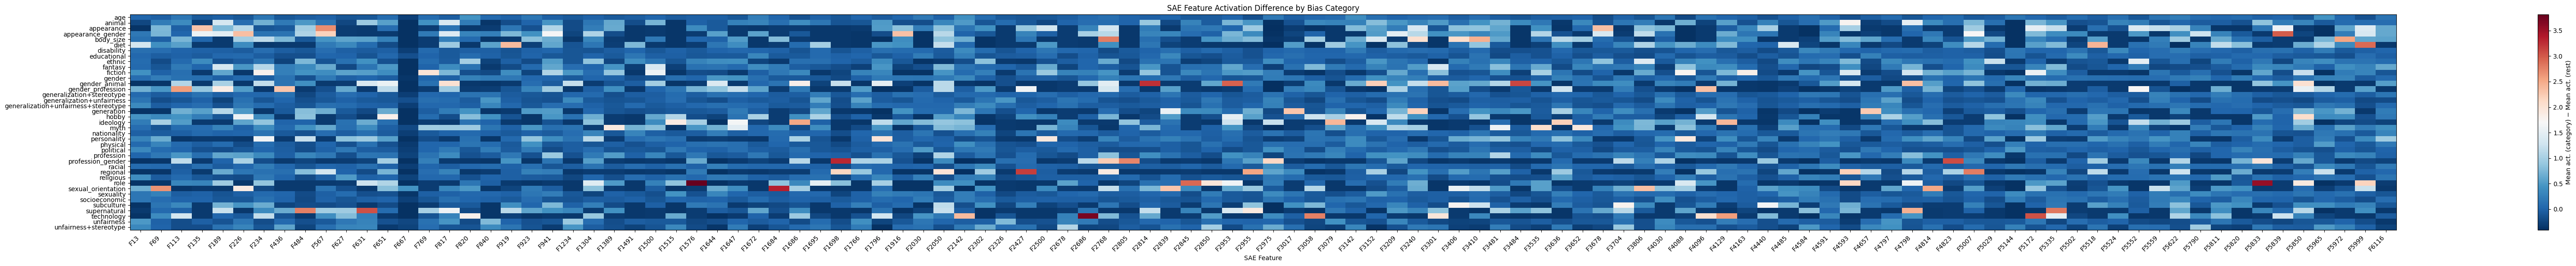

In [21]:
# Heatmap: top features × bias categories
# Collect union of top features across categories
all_top_feats = sorted(set(f for fs in category_top_features.values() for f in fs))
sorted_cats   = sorted(categories)

heatmap_data = np.zeros((len(sorted_cats), len(all_top_feats)))
for i, cat in enumerate(sorted_cats):
    cat_mask   = (df["bias_type"] == cat).values
    other_mask = ~cat_mask
    for j, fi in enumerate(all_top_feats):
        heatmap_data[i, j] = (
            all_features[cat_mask, fi].mean() - all_features[other_mask, fi].mean()
        )

fig, ax = plt.subplots(figsize=(max(10, len(all_top_feats) * 0.6), 6))
im = ax.imshow(heatmap_data, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(len(all_top_feats)))
ax.set_xticklabels([f"F{f}" for f in all_top_feats], rotation=45, ha="right")
ax.set_yticks(range(len(sorted_cats)))
ax.set_yticklabels(sorted_cats)
ax.set_title("SAE Feature Activation Difference by Bias Category")
ax.set_xlabel("SAE Feature")
plt.colorbar(im, ax=ax, label="Mean act. (category) − Mean act. (rest)")
plt.tight_layout()
plt.show()

## 9. Layer Sweep (Optional)

Train a SAE at each layer to see **where** bias information is most
concentrated in the residual stream.

In [25]:
SWEEP_LAYERS = [0,1, 2, 3,4, 5,6, 7,8, 9,10, 11]  # subset for speed
SWEEP_EPOCHS = 15  # fewer epochs for sweep

layer_stats = []

for layer in SWEEP_LAYERS:
    print(f"\n── Layer {layer} ──")
    hook = f"blocks.{layer}.hook_resid_post"

    # Extract activations for this layer
    layer_acts = []
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"  Activations L{layer}", leave=False):
        tokens = model.to_tokens(row["text"], prepend_bos=True)
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=[hook])
        mean_act = cache[hook][0, 1:].mean(dim=0).cpu()
        layer_acts.append(mean_act)

    layer_acts_t = torch.stack(layer_acts)
    la_mean = layer_acts_t.mean(0)
    la_std  = layer_acts_t.std(0).clamp(min=1e-6)
    la_norm = ((layer_acts_t - la_mean) / la_std).to(DEVICE)

    # Train SAE
    layer_sae = SparseAutoencoder(D_MODEL, D_SAE, l1_coeff=L1_COEFF).to(DEVICE)
    layer_opt = torch.optim.Adam(layer_sae.parameters(), lr=SAE_LR)
    layer_dl  = DataLoader(TensorDataset(la_norm), batch_size=SAE_BATCH_SIZE,
                           shuffle=True, drop_last=True)

    for _ in range(SWEEP_EPOCHS):
        for (batch,) in layer_dl:
            loss, _, _ = layer_sae.loss(batch)
            loss.backward()
            with torch.no_grad():
                layer_sae.decoder.weight.data = F.normalize(
                    layer_sae.decoder.weight.data, dim=0
                )
            layer_opt.step()
            layer_opt.zero_grad()

    # Evaluate
    layer_sae.eval()
    with torch.no_grad():
        _, feats = layer_sae(la_norm)
        feats_np = feats.cpu().numpy()

    b_mean = feats_np[biased_mask].mean(0)
    n_mean = feats_np[neutral_mask].mean(0)
    d      = b_mean - n_mean

    n_sig = 0
    active = (feats_np > 0).any(axis=0)
    for i in range(D_SAE):
        if not active[i]:
            continue
        _, p = stats.mannwhitneyu(
            feats_np[biased_mask, i], feats_np[neutral_mask, i], alternative="two-sided"
        )
        if p * active.sum() < 0.05:
            n_sig += 1

    layer_stats.append({
        "layer": layer,
        "n_significant": n_sig,
        "max_abs_diff": np.abs(d).max(),
        "n_active": int(active.sum()),
    })
    print(f"  Significant: {n_sig} │ Active: {active.sum()} │ Max |diff|: {np.abs(d).max():.4f}")

sweep_df = pd.DataFrame(layer_stats)
print("\n" + sweep_df.to_string(index=False))


── Layer 0 ──


  Activations L0:   0%|          | 0/5700 [00:00<?, ?it/s]

  Significant: 3536 │ Active: 6144 │ Max |diff|: 0.4649

── Layer 1 ──


  Activations L1:   0%|          | 0/5700 [00:00<?, ?it/s]

  Significant: 3759 │ Active: 6144 │ Max |diff|: 0.5077

── Layer 2 ──


...

  Significant: 4042 │ Active: 6144 │ Max |diff|: 0.7832

── Layer 10 ──


  Activations L10:   0%|          | 0/5700 [00:00<?, ?it/s]

  Significant: 3970 │ Active: 6144 │ Max |diff|: 0.6479

── Layer 11 ──


  Activations L11:   0%|          | 0/5700 [00:00<?, ?it/s]

  Significant: 3903 │ Active: 6144 │ Max |diff|: 0.5319

 layer  n_significant  max_abs_diff  n_active
     0           3536      0.464942      6144
     1           3759      0.507714      6144
     2           3766      0.540387      6144
     3           3764      0.542063      6144
     4           3744      0.569560      6144
     5           3852      0.630917      6144
     6           3978      0.620897      6144
     7           3919      0.639026      6144
     8           4000      0.636551      6144
     9           4042      0.783235      6144
    10           3970      0.647883      6144
    11           3903      0.531924      6144


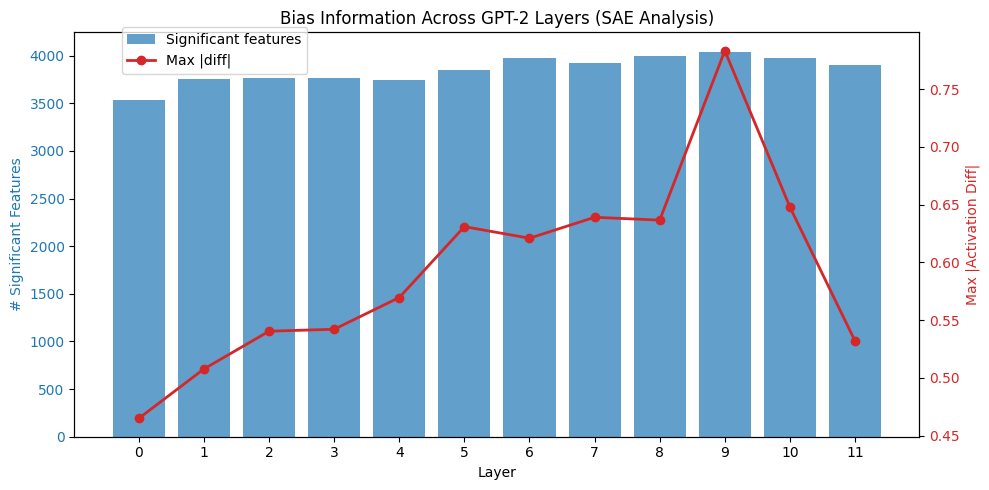

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(sweep_df["layer"], sweep_df["n_significant"], color="tab:blue", alpha=0.7,
        label="Significant features")
ax1.set_xlabel("Layer")
ax1.set_ylabel("# Significant Features", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(sweep_df["layer"])

ax2 = ax1.twinx()
ax2.plot(sweep_df["layer"], sweep_df["max_abs_diff"], color="tab:red",
         marker="o", linewidth=2, label="Max |diff|")
ax2.set_ylabel("Max |Activation Diff|", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.95))
plt.title("Bias Information Across GPT-2 Layers (SAE Analysis)")
plt.tight_layout()
plt.show()

## 10. Export Results

In [27]:
# Save feature analysis
results_df.to_csv("sae_feature_analysis_12.csv", index=False)
print("Saved: sae_feature_analysis_12.csv")

# Save SAE weights
torch.save({
    "model_state_dict": sae.state_dict(),
    "config": {
        "d_input": D_MODEL,
        "d_hidden": D_SAE,
        "l1_coeff": L1_COEFF,
        "hook_layer": HOOK_LAYER,
        "model_name": MODEL_NAME,
    },
    "normalization": {
        "mean": acts_mean,
        "std": acts_std,
    }
}, "sae_checkpoint.pt")
print("Saved: sae_checkpoint_12.pt")

if len(layer_stats) > 0:
    sweep_df.to_csv("sae_layer_sweep_12.csv", index=False)
    print("Saved: sae_layer_sweep_12.csv")

# Download from Colab
from google.colab import files
files.download("sae_feature_analysis_12.csv")
files.download("sae_checkpoint_12.pt")

Saved: sae_feature_analysis_12.csv
Saved: sae_checkpoint_12.pt
Saved: sae_layer_sweep_12.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: sae_checkpoint_12.pt

## Summary

### What this analysis shows

- **SAE features are learned without labels** — the autoencoder discovers
  interpretable directions in GPT-2's activation space purely from
  reconstruction + sparsity.
- **Some features correlate with bias** — statistical testing identifies
  features that activate differently for biased vs. neutral text.
- **Per-category patterns** — different bias types (gender, racial, etc.)
  may activate different SAE features, revealing how bias is encoded.
- **Layer sweep** — shows where in the network bias information is most
  accessible to the SAE.

### Next steps

1. **Compare with attention heads** — do the layers where SAE finds most
   discriminative features match the important attention heads from the
   classification pipeline?
2. **Use pre-trained SAEs** (SAELens) for comparison with features learned
   on a large generic corpus.
3. **Fine-tuned model analysis** — run the same analysis on GUSNet's
   fine-tuned GPT-2 to see how training changes the features.
4. **Feature circuits** — trace which SAE features compose through layers
   using techniques from mechanistic interpretability.